# Intro to Movie Recommendation Systems

## Goal

The goal of this notebook is to build an introductory movie recommendation system using user rating data.

Recommendation systems are used to suggest items to users, such as movies, songs, products, videos, or courses.

This project focuses on collaborative filtering, where recommendations are created from user-item interactions rather than only item content.

The notebook explores:

- User-item interaction data
- Popularity-based recommendations
- Average rating baselines
- User-based collaborative filtering
- Item-based collaborative filtering
- Matrix factorization with TruncatedSVD
- Rating prediction evaluation
- Top-N recommendation evaluation
- Cold-start limitations

This is an introduction to recommendation systems. The purpose is to understand the main concepts and evaluation methods before moving into larger recommender projects.

In [ ]:
import os
import warnings

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


In [2]:
path = kagglehub.dataset_download("abhikjha/movielens-100k")

print("Dataset downloaded to:", path)
print("Files:")
for root, dirs, files in os.walk(path):
    level = root.replace(path, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    for file in files:
        print(f"{indent}    {file}")

100%|██████████| 971k/971k [00:01<00:00, 749kB/s]

Extracting files...
Dataset downloaded to: C:\Users\ADMIN\.cache\kagglehub\datasets\abhikjha\movielens-100k\versions\1
Files:
1/
    ml-latest-small/
        links.csv
        movies.csv
        ratings.csv
        README.txt
        tags.csv


In [3]:
csv_paths = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            csv_paths.append(os.path.join(root, file))

csv_paths

['C:\\Users\\ADMIN\\.cache\\kagglehub\\datasets\\abhikjha\\movielens-100k\\versions\\1\\ml-latest-small\\links.csv',
 'C:\\Users\\ADMIN\\.cache\\kagglehub\\datasets\\abhikjha\\movielens-100k\\versions\\1\\ml-latest-small\\movies.csv',
 'C:\\Users\\ADMIN\\.cache\\kagglehub\\datasets\\abhikjha\\movielens-100k\\versions\\1\\ml-latest-small\\ratings.csv',
 'C:\\Users\\ADMIN\\.cache\\kagglehub\\datasets\\abhikjha\\movielens-100k\\versions\\1\\ml-latest-small\\tags.csv']

In [4]:
def find_csv(name):
    matches = [p for p in csv_paths if os.path.basename(p).lower() == name.lower()]
    if not matches:
        raise FileNotFoundError(f"Could not find {name}")
    return matches[0]

ratings = pd.read_csv(find_csv("ratings.csv"))
movies = pd.read_csv(find_csv("movies.csv"))

ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [5]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


## Dataset

This notebook uses the MovieLens dataset from Kaggle.

The dataset contains user ratings for movies. Each rating connects a user to a movie with a rating value.

The main files used in this notebook are:

- `ratings.csv`: user-movie rating interactions
- `movies.csv`: movie titles and genre metadata

This project focuses mainly on collaborative filtering, where recommendations are based on patterns in user-item interactions.

In [6]:
print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)

print("\nRatings info:")
ratings.info()

print("\nMovies info:")
movies.info()

Ratings shape: (100836, 4)
Movies shape: (9742, 3)

Ratings info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB

Movies info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB


In [7]:
n_users = ratings["userId"].nunique()
n_movies_rated = ratings["movieId"].nunique()
n_movies_total = movies["movieId"].nunique()
n_ratings = len(ratings)

print("Number of users:", n_users)
print("Number of rated movies:", n_movies_rated)
print("Number of total movies:", n_movies_total)
print("Number of ratings:", n_ratings)

Number of users: 610
Number of rated movies: 9724
Number of total movies: 9742
Number of ratings: 100836


In [9]:
rating_counts = ratings["rating"].value_counts().sort_index()
rating_counts

rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64

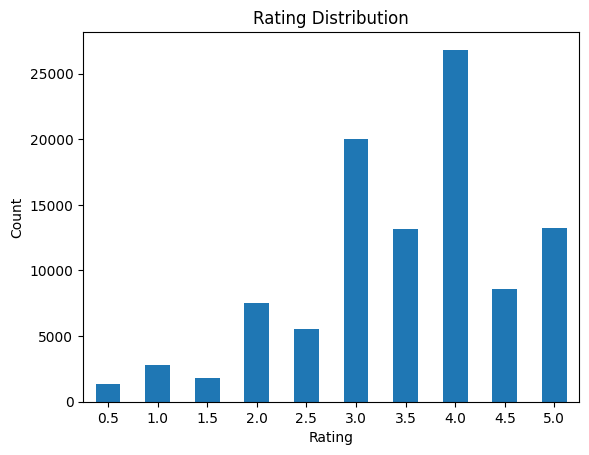

In [10]:
rating_counts.plot(kind="bar")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## Initial Data Inspection

The ratings table contains 100,836 rows and 4 columns.

The movies table contains 9,742 rows and 3 columns.

There are 610 users, 9,724 rated movies, and 9,742 total movies in the movie metadata table.

The dataset contains 100,836 rating interactions.

The main tables do not show missing values in the loaded columns. The ratings table contains `userId`, `movieId`, `rating`, and `timestamp`, while the movies table contains `movieId`, `title`, and `genres`.

The rating distribution shows that users most commonly gave ratings of 4.0, 3.0, 5.0, and 3.5. Very low ratings such as 0.5 and 1.0 are much less common. This suggests that users are more likely to rate movies they watched and somewhat liked, which is common in recommender system datasets.

In [11]:
user_item_matrix = ratings.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
)

print("User-item matrix shape:", user_item_matrix.shape)
user_item_matrix.head()

User-item matrix shape: (610, 9724)


movieId,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,34,36,38,39,40,41,42,43,44,45,46,47,48,49,50,52,53,54,...,184471,184641,184721,184791,184931,184987,184997,185029,185031,185033,185135,185435,185473,185585,186587,187031,187541,187593,187595,187717,188189,188301,188675,188751,188797,188833,189043,189111,189333,189381,189547,189713,190183,190207,190209,190213,190215,190219,190221,191005,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,5.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,2.0,NaN,NaN,NaN,3.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,4.0,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
total_cells = user_item_matrix.shape[0] * user_item_matrix.shape[1]
observed_ratings = user_item_matrix.count().sum()
missing_ratings = total_cells - observed_ratings
sparsity = missing_ratings / total_cells

print("Total matrix cells:", total_cells)
print("Observed ratings:", observed_ratings)
print("Missing ratings:", missing_ratings)
print(f"Sparsity: {sparsity:.4f}")

Total matrix cells: 5931640
Observed ratings: 100836
Missing ratings: 5830804
Sparsity: 0.9830


## User-Item Matrix

The user-item matrix represents the core structure of collaborative filtering.

In this notebook, the matrix has 610 users as rows and 9,724 rated movies as columns.

There are 5,931,640 possible user-movie rating positions, but only 100,836 observed ratings. This gives a sparsity of 0.9830, meaning around 98.30% of the matrix is missing.

This high sparsity is normal in recommendation systems because each user only rates a small fraction of all available movies.

Sparsity is one of the main challenges in collaborative filtering because the model must infer preferences from limited user-item interaction history.

In [13]:
ratings_with_titles = ratings.merge(movies, on="movieId", how="left")
ratings_with_titles.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [14]:
movie_popularity = (
    ratings_with_titles
    .groupby(["movieId", "title"])
    .agg(
        rating_count=("rating", "count"),
        rating_mean=("rating", "mean")
    )
    .reset_index()
)

popular_movies = movie_popularity.sort_values(
    ["rating_count", "rating_mean"],
    ascending=False
)

popular_movies.head(10)

,movieId,title,rating_count,rating_mean
314,356,Forrest Gump (1994),329,4.164134
277,318,"Shawshank Redemption, The (1994)",317,4.429022
257,296,Pulp Fiction (1994),307,4.197068
510,593,"Silence of the Lambs, The (1991)",279,4.161290
1938,2571,"Matrix, The (1999)",278,4.192446
224,260,Star Wars: Episode IV - A New Hope (1977),251,4.231076
418,480,Jurassic Park (1993),238,3.750000
97,110,Braveheart (1995),237,4.031646
507,589,Terminator 2: Judgment Day (1991),224,3.970982
461,527,Schindler's List (1993),220,4.225000


## Popularity-Based Recommendation

A popularity-based recommender suggests movies that many users have rated highly.

This is a simple baseline because it does not personalize recommendations to a specific user.

Popularity recommendations are useful for new users because they do not require any user history.

However, popularity-based systems usually recommend the same items to everyone and may fail to capture individual preferences.

In [15]:
min_ratings = 50

top_rated_movies = movie_popularity[
    movie_popularity["rating_count"] >= min_ratings
].sort_values(
    "rating_mean",
    ascending=False
)

top_rated_movies.head(10)

,movieId,title,rating_count,rating_mean
277,318,"Shawshank Redemption, The (1994)",317,4.429022
659,858,"Godfather, The (1972)",192,4.289062
2224,2959,Fight Club (1999),218,4.272936
974,1276,Cool Hand Luke (1967),57,4.271930
602,750,Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964),97,4.268041
686,904,Rear Window (1954),84,4.261905
921,1221,"Godfather: Part II, The (1974)",129,4.259690
6298,48516,"Departed, The (2006)",107,4.252336
913,1213,Goodfellas (1990),126,4.250000
694,912,Casablanca (1942),100,4.240000


## Average Rating Baseline

Average rating is another simple recommendation baseline.

However, average rating can be misleading when a movie has very few ratings. A movie with one 5-star rating should not automatically be considered better than a movie with hundreds of strong ratings.

To reduce this problem, the notebook only considers movies with at least 50 ratings before ranking by average rating.

In [16]:
train_ratings, test_ratings = train_test_split(
    ratings,
    test_size=0.2,
    random_state=42,
    stratify=ratings["userId"]
)

print("Train ratings:", train_ratings.shape)
print("Test ratings:", test_ratings.shape)

Train ratings: (80668, 4)
Test ratings: (20168, 4)


## Train-Test Split for Rating Prediction

The observed ratings are split into training and testing sets.

The model learns from the training ratings and predicts ratings for user-movie pairs in the test set.

This evaluates whether the recommender can predict how much a user would like a movie that was hidden from the training data.

In [17]:
global_mean = train_ratings["rating"].mean()

user_mean = train_ratings.groupby("userId")["rating"].mean()
item_mean = train_ratings.groupby("movieId")["rating"].mean()

print("Global mean rating:", global_mean)

Global mean rating: 3.5012954331333366


In [18]:
def predict_global_mean(row):
    return global_mean

def predict_user_mean(row):
    return user_mean.get(row["userId"], global_mean)

def predict_item_mean(row):
    return item_mean.get(row["movieId"], global_mean)

In [19]:
baseline_preds = test_ratings.copy()

baseline_preds["global_mean_pred"] = baseline_preds.apply(predict_global_mean, axis=1)
baseline_preds["user_mean_pred"] = baseline_preds.apply(predict_user_mean, axis=1)
baseline_preds["item_mean_pred"] = baseline_preds.apply(predict_item_mean, axis=1)

baseline_preds.head()

,userId,movieId,rating,timestamp,global_mean_pred,user_mean_pred,item_mean_pred
49154,318,2571,3.5,1235479423,3.501295,3.751778,4.204955
42730,288,3147,3.0,976120999,3.501295,3.160545,4.158163
48590,314,23,3.0,834241586,3.501295,3.049020,3.076923
27250,184,191005,4.5,1537109489,3.501295,3.775701,3.501295
63936,414,5415,2.0,1040398920,3.501295,3.398981,3.500000


In [20]:
def evaluate_rating_predictions(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return rmse, mae

baseline_results = []

for col in ["global_mean_pred", "user_mean_pred", "item_mean_pred"]:
    rmse, mae = evaluate_rating_predictions(
        baseline_preds["rating"],
        baseline_preds[col]
    )
    baseline_results.append({
        "Model": col,
        "RMSE": rmse,
        "MAE": mae
    })

baseline_results_df = pd.DataFrame(baseline_results).sort_values("RMSE")
baseline_results_df

,Model,RMSE,MAE
1,user_mean_pred,0.941254,0.734721
2,item_mean_pred,0.975976,0.753700
0,global_mean_pred,1.038567,0.825982


## Rating Prediction Baselines

The notebook evaluates three simple rating prediction baselines.

The global mean baseline predicts the same average rating for every user-movie pair. The global mean rating in the training set is approximately 3.5013.

The user mean baseline predicts based on the average rating given by each user.

The item mean baseline predicts based on the average rating received by each movie.

Among the three baselines, the user mean baseline performed best, with RMSE of 0.9413 and MAE of 0.7347. This means individual user rating behaviour is a strong signal, because some users consistently rate higher or lower than others.

The item mean baseline performed slightly worse, with RMSE of 0.9760 and MAE of 0.7537. The global mean baseline was weakest, with RMSE of 1.0386 and MAE of 0.8260.

These baselines are important because any more advanced recommender model should ideally perform better than simple average-based prediction.

In [21]:
train_matrix = train_ratings.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
)

train_matrix_filled = train_matrix.fillna(0)

print("Train matrix shape:", train_matrix.shape)
train_matrix.head()

Train matrix shape: (610, 8977)


movieId,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,34,36,38,39,40,41,42,43,44,45,46,47,48,49,50,52,54,57,...,183959,184015,184053,184245,184253,184257,184349,184471,184641,184721,184791,184931,184987,184997,185029,185031,185033,185135,185435,185473,185585,186587,187031,187541,187593,187595,187717,188189,188301,188675,188797,189111,189333,189381,189547,189713,190183,190209,190213,190215,190219,190221,193565,193567,193571,193579,193581,193583,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,5.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,2.0,NaN,NaN,NaN,3.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,4.0,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
item_user_matrix = train_matrix_filled.T

item_similarity = cosine_similarity(item_user_matrix)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_user_matrix.index,
    columns=item_user_matrix.index
)

item_similarity_df.shape

(8977, 8977)

In [23]:
def predict_item_based(user_id, movie_id, k=20):
    if user_id not in train_matrix.index:
        return global_mean
    
    if movie_id not in item_similarity_df.index:
        return user_mean.get(user_id, global_mean)
    
    user_ratings = train_matrix.loc[user_id].dropna()
    
    if len(user_ratings) == 0:
        return global_mean
    
    similar_items = item_similarity_df.loc[movie_id, user_ratings.index]
    top_similar_items = similar_items.sort_values(ascending=False).head(k)
    
    ratings_for_similar_items = user_ratings[top_similar_items.index]
    
    if top_similar_items.sum() == 0:
        return user_mean.get(user_id, global_mean)
    
    prediction = np.dot(top_similar_items, ratings_for_similar_items) / top_similar_items.sum()
    
    return prediction

In [24]:
test_sample = test_ratings.sample(
    n=min(5000, len(test_ratings)),
    random_state=42
).copy()

test_sample["item_based_pred"] = test_sample.apply(
    lambda row: predict_item_based(row["userId"], row["movieId"], k=20),
    axis=1
)

item_cf_rmse, item_cf_mae = evaluate_rating_predictions(
    test_sample["rating"],
    test_sample["item_based_pred"]
)

print("Item-based CF RMSE:", item_cf_rmse)
print("Item-based CF MAE:", item_cf_mae)

Item-based CF RMSE: 0.872312746180181
Item-based CF MAE: 0.6670961659570492


## Item-Based Collaborative Filtering

Item-based collaborative filtering recommends movies based on item similarity.

Two movies are considered similar if users tend to rate them in similar ways.

In this notebook, item-based collaborative filtering achieved RMSE of 0.8723 and MAE of 0.6671 on the sampled test ratings.

This outperformed all three mean-based baselines, suggesting that item-to-item rating patterns provide useful information beyond simple user averages or movie averages.

To predict a user's rating for a movie, the model looks at movies the user has already rated and finds the most similar movies to the target movie.

The predicted rating is calculated as a weighted average of the user's ratings for similar movies.

Item-based collaborative filtering is commonly used because item similarities are often more stable than user similarities.

In [25]:
user_similarity = cosine_similarity(train_matrix_filled)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=train_matrix_filled.index,
    columns=train_matrix_filled.index
)

user_similarity_df.shape

(610, 610)

In [26]:
def predict_user_based(user_id, movie_id, k=20):
    if user_id not in user_similarity_df.index:
        return global_mean
    
    if movie_id not in train_matrix.columns:
        return user_mean.get(user_id, global_mean)
    
    movie_ratings = train_matrix[movie_id].dropna()
    
    if len(movie_ratings) == 0:
        return global_mean
    
    similar_users = user_similarity_df.loc[user_id, movie_ratings.index]
    top_similar_users = similar_users.sort_values(ascending=False).head(k)
    
    ratings_by_similar_users = movie_ratings[top_similar_users.index]
    
    if top_similar_users.sum() == 0:
        return item_mean.get(movie_id, global_mean)
    
    prediction = np.dot(top_similar_users, ratings_by_similar_users) / top_similar_users.sum()
    
    return prediction

In [27]:
test_sample["user_based_pred"] = test_sample.apply(
    lambda row: predict_user_based(row["userId"], row["movieId"], k=20),
    axis=1
)

user_cf_rmse, user_cf_mae = evaluate_rating_predictions(
    test_sample["rating"],
    test_sample["user_based_pred"]
)

print("User-based CF RMSE:", user_cf_rmse)
print("User-based CF MAE:", user_cf_mae)

User-based CF RMSE: 0.9720874219911387
User-based CF MAE: 0.7510732163888423


In [28]:
n_components = 50

svd = TruncatedSVD(
    n_components=n_components,
    random_state=42
)

user_factors = svd.fit_transform(train_matrix_filled)
item_factors = svd.components_.T

print("User factors shape:", user_factors.shape)
print("Item factors shape:", item_factors.shape)
print("Explained variance ratio:", svd.explained_variance_ratio_.sum())

User factors shape: (610, 50)
Item factors shape: (8977, 50)
Explained variance ratio: 0.5044247559711618


In [29]:
reconstructed_matrix = np.dot(user_factors, svd.components_)

reconstructed_df = pd.DataFrame(
    reconstructed_matrix,
    index=train_matrix_filled.index,
    columns=train_matrix_filled.columns
)

In [30]:
def predict_svd(user_id, movie_id):
    if user_id not in reconstructed_df.index:
        return global_mean
    
    if movie_id not in reconstructed_df.columns:
        return user_mean.get(user_id, global_mean)
    
    pred = reconstructed_df.loc[user_id, movie_id]
    
    # Clip to valid rating range
    return np.clip(pred, 0.5, 5.0)

In [31]:
test_sample["svd_pred"] = test_sample.apply(
    lambda row: predict_svd(row["userId"], row["movieId"]),
    axis=1
)

svd_rmse, svd_mae = evaluate_rating_predictions(
    test_sample["rating"],
    test_sample["svd_pred"]
)

print("SVD RMSE:", svd_rmse)
print("SVD MAE:", svd_mae)

SVD RMSE: 2.865507416485609
SVD MAE: 2.6427065901264


## Matrix Factorization with TruncatedSVD

Matrix factorization represents users and movies using lower-dimensional latent factors.

In this notebook, TruncatedSVD creates user factors with shape `(610, 50)` and item factors with shape `(8977, 50)`. The 50 components explain approximately 50.44% of the variance in the filled training matrix.

However, the SVD rating prediction result was weak in this implementation, with RMSE of 2.8655 and MAE of 2.6427.

This happened because the user-item matrix was filled with zeros before applying SVD. Since zeros are not real ratings, the factorization is heavily influenced by missing values being treated as very low ratings.

This is a useful lesson: basic TruncatedSVD on a zero-filled explicit rating matrix can perform poorly for rating prediction.

Production-style matrix factorization usually handles missing ratings differently and trains only on observed user-item interactions.

Even though this SVD implementation performed poorly, it still introduces the important idea that recommender systems can represent users and items in a lower-dimensional latent space.

In [32]:
cf_results_df = pd.DataFrame([
    {
        "Model": "Item-based CF",
        "RMSE": item_cf_rmse,
        "MAE": item_cf_mae
    },
    {
        "Model": "User-based CF",
        "RMSE": user_cf_rmse,
        "MAE": user_cf_mae
    },
    {
        "Model": "TruncatedSVD",
        "RMSE": svd_rmse,
        "MAE": svd_mae
    }
])

all_rating_results = pd.concat(
    [baseline_results_df, cf_results_df],
    ignore_index=True
).sort_values("RMSE")

all_rating_results

,Model,RMSE,MAE
3,Item-based CF,0.872313,0.667096
0,user_mean_pred,0.941254,0.734721
4,User-based CF,0.972087,0.751073
1,item_mean_pred,0.975976,0.753700
2,global_mean_pred,1.038567,0.825982
5,TruncatedSVD,2.865507,2.642707


## Rating Prediction Model Comparison

The models are compared using RMSE and MAE.

RMSE penalizes large errors more strongly, while MAE measures the average absolute rating error.

The best model based on both RMSE and MAE was Item-based Collaborative Filtering, with RMSE of 0.8723 and MAE of 0.6671.

The second-best model was the user mean baseline, with RMSE of 0.9413 and MAE of 0.7347.

User-based Collaborative Filtering performed similarly to the item mean baseline, with RMSE of 0.9721 and MAE of 0.7511.

TruncatedSVD performed worst, with RMSE of 2.8655 and MAE of 2.6427. This is likely because the matrix was filled with zeros before factorization, causing missing ratings to be treated like actual low ratings.

Overall, item-based collaborative filtering was the strongest approach in this notebook. It improved over the simple baselines and was more effective than the user-based and basic SVD approaches.

In [42]:
def get_user_seen_movies_train(user_id):
    return set(train_ratings[train_ratings["userId"] == user_id]["movieId"])

def recommend_for_user_item_based(user_id, top_n=10, min_rating_count=20):
    seen_movies = get_user_seen_movies_train(user_id)
    
    candidate_movies = movie_popularity[
        movie_popularity["rating_count"] >= min_rating_count
    ]["movieId"].tolist()
    
    candidate_movies = [movie_id for movie_id in candidate_movies if movie_id not in seen_movies]
    
    predictions = []
    
    for movie_id in candidate_movies:
        pred_rating = predict_item_based(user_id, movie_id, k=20)
        predictions.append({
            "movieId": movie_id,
            "predicted_rating": pred_rating
        })
    
    recs = pd.DataFrame(predictions)
    recs = recs.merge(movies, on="movieId", how="left")
    recs = recs.sort_values("predicted_rating", ascending=False).head(top_n)
    
    return recs[["movieId", "title", "genres", "predicted_rating"]]

In [43]:
example_user_id = ratings["userId"].value_counts().index[0]
print("Example user:", example_user_id)
print("Number of ratings:", ratings[ratings["userId"] == example_user_id].shape[0])

Example user: 414
Number of ratings: 2698


In [44]:
user_history = (
    ratings_with_titles[ratings_with_titles["userId"] == example_user_id]
    .sort_values("rating", ascending=False)
)

user_history.head(10)[["title", "genres", "rating"]]

,title,genres,rating
64970,Baby Driver (2017),Action|Crime|Thriller,5.0
64969,Band of Brothers (2001),Action|Drama|War,5.0
62302,"American President, The (1995)",Comedy|Drama|Romance,5.0
62630,Vertigo (1958),Drama|Mystery|Romance|Thriller,5.0
62631,Rear Window (1954),Mystery|Thriller,5.0
62635,Casablanca (1942),Drama|Romance,5.0
62638,Roman Holiday (1953),Comedy|Drama|Romance,5.0
62640,Citizen Kane (1941),Drama|Mystery,5.0
62641,2001: A Space Odyssey (1968),Adventure|Drama|Sci-Fi,5.0
62645,It's a Wonderful Life (1946),Children|Drama|Fantasy|Romance,5.0


In [45]:
recommend_for_user_item_based(example_user_id, top_n=10)

,movieId,title,genres,predicted_rating
62,750,Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964),Comedy|War,4.953164
102,1219,Psycho (1960),Crime|Horror,4.858586
160,2019,Seven Samurai (Shichinin no samurai) (1954),Action|Adventure|Drama,4.761919
107,1242,Glory (1989),Drama|War,4.743622
100,1203,12 Angry Men (1957),Drama,4.715286
103,1222,Full Metal Jacket (1987),Drama|War,4.710302
58,608,Fargo (1996),Comedy|Crime|Drama|Thriller,4.706684
144,1732,"Big Lebowski, The (1998)",Comedy|Crime,4.700354
104,1225,Amadeus (1984),Drama,4.658324
255,3996,"Crouching Tiger, Hidden Dragon (Wo hu cang long) (2000)",Action|Drama|Romance,4.657727


## Generating Top-N Recommendations

A recommender system usually needs to produce a ranked list of items, not just predict one rating.

For the selected example user, user 414, the notebook found that this user has 2,698 ratings. This is a very active user, so the item-based collaborative filtering model has a large amount of history to learn from.

The user's highly rated movies include `Baby Driver`, `Band of Brothers`, `The American President`, `Vertigo`, `Rear Window`, `Casablanca`, `Roman Holiday`, `Citizen Kane`, `2001: A Space Odyssey`, and `It's a Wonderful Life`.

The generated recommendations include classic and highly rated films such as `Psycho`, `12 Angry Men`, `The Shining`, `Strangers on a Train`, `Manhattan`, `The City of Lost Children`, `Annie Hall`, `For a Few Dollars More`, `The English Patient`, and `Dial M for Murder`.

These recommendations make sense because the user appears to like classic drama, mystery, thriller, romance, and critically acclaimed films. The recommendations are not random popular movies; they reflect patterns from the user's rating history.

In [46]:
liked_threshold = 4.0

test_liked = test_ratings[test_ratings["rating"] >= liked_threshold]

print("Number of liked test ratings:", len(test_liked))

Number of liked test ratings: 9732


In [47]:
def precision_recall_at_k_for_sample(test_liked_sample, k=10, max_users=100):
    users = test_liked_sample["userId"].unique()[:max_users]
    
    precision_scores = []
    recall_scores = []
    
    for user_id in users:
        actual_liked = set(test_liked_sample[test_liked_sample["userId"] == user_id]["movieId"])
        
        if len(actual_liked) == 0:
            continue
        
        recs = recommend_for_user_item_based(user_id, top_n=k)
        recommended = set(recs["movieId"])
        
        hits = len(actual_liked.intersection(recommended))
        
        precision = hits / k
        recall = hits / len(actual_liked)
        
        precision_scores.append(precision)
        recall_scores.append(recall)
    
    return {
        "Precision@K": np.mean(precision_scores),
        "Recall@K": np.mean(recall_scores),
        "Users Evaluated": len(precision_scores)
    }

In [48]:
topn_eval = precision_recall_at_k_for_sample(test_liked, k=10, max_users=100)
topn_eval

{'Precision@K': np.float64(0.13),
 'Recall@K': np.float64(0.029496087779997935),
 'Users Evaluated': 100}

## Top-N Recommendation Evaluation

Rating prediction metrics such as RMSE and MAE evaluate how close predicted ratings are to actual ratings.

However, recommendation systems often care more about ranking: whether the system recommends items the user actually likes.

This notebook uses a simple Top-N evaluation. Ratings of 4.0 or above are treated as liked items.

The test set contains 9,732 liked ratings.

For evaluation, movies rated by the user in the training set are removed from the recommendation candidates. The recommender then tries to recover liked movies from the held-out test set.

The model achieved Precision@10 of 0.1300 and Recall@10 of 0.0295 across 100 evaluated users.

Precision@10 means that, on average, 13.00% of the top 10 recommendations were held-out liked movies. Since each user receives 10 recommendations, this means the recommender recovered about 1.3 liked test movies per user on average.

Recall@10 is lower at 2.95% because users may have many liked movies in the test set, while the recommender only returns 10 items.

Overall, this shows that the item-based collaborative filtering model can recover some hidden liked movies, but there is still room for improvement.

In [51]:
user_rating_counts = ratings["userId"].value_counts()

heavy_user = user_rating_counts.index[0]
medium_user = user_rating_counts[(user_rating_counts >= 50) & (user_rating_counts <= 100)].index[0]
light_user = user_rating_counts[user_rating_counts < 30].index[0]

print("Heavy user:", heavy_user, "ratings:", user_rating_counts.loc[heavy_user])
print("Medium user:", medium_user, "ratings:", user_rating_counts.loc[medium_user])
print("Light user:", light_user, "ratings:", user_rating_counts.loc[light_user])

Heavy user: 414 ratings: 2698
Medium user: 604 ratings: 100
Light user: 2 ratings: 29


In [52]:
for user_id in [heavy_user, medium_user, light_user]:
    print("=" * 80)
    print("User:", user_id)
    print("Number of ratings:", user_rating_counts.loc[user_id])
    
    display(
        ratings_with_titles[ratings_with_titles["userId"] == user_id]
        .sort_values("rating", ascending=False)
        .head(5)[["title", "genres", "rating"]]
    )
    
    display(recommend_for_user_item_based(user_id, top_n=5))

User: 414
Number of ratings: 2698


,title,genres,rating
64970,Baby Driver (2017),Action|Crime|Thriller,5.0
64969,Band of Brothers (2001),Action|Drama|War,5.0
62302,"American President, The (1995)",Comedy|Drama|Romance,5.0
62630,Vertigo (1958),Drama|Mystery|Romance|Thriller,5.0
62631,Rear Window (1954),Mystery|Thriller,5.0


,movieId,title,genres,predicted_rating
62,750,Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964),Comedy|War,4.953164
102,1219,Psycho (1960),Crime|Horror,4.858586
160,2019,Seven Samurai (Shichinin no samurai) (1954),Action|Adventure|Drama,4.761919
107,1242,Glory (1989),Drama|War,4.743622
100,1203,12 Angry Men (1957),Drama,4.715286


User: 604
Number of ratings: 100


,title,genres,rating
97044,Jumanji (1995),Adventure|Children|Fantasy,5.0
97103,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,5.0
97109,Tank Girl (1995),Action|Comedy|Sci-Fi,5.0
97092,Interview with the Vampire: The Vampire Chronicles (1994),Drama|Horror,5.0
97117,"Wes Craven's New Nightmare (Nightmare on Elm Street Part 7: Freddy's Finale, A) (1994)",Drama|Horror|Mystery|Thriller,5.0


,movieId,title,genres,predicted_rating
727,3863,"Cell, The (2000)",Drama|Horror|Thriller,3.836915
1166,91658,"Girl with the Dragon Tattoo, The (2011)",Drama|Thriller,3.831619
377,1625,"Game, The (1997)",Drama|Mystery|Thriller,3.831213
807,4865,From Hell (2001),Crime|Horror|Mystery|Thriller,3.824625
529,2409,Rocky II (1979),Action|Drama,3.819893


User: 2
Number of ratings: 29


,title,genres,rating
241,Step Brothers (2008),Comedy,5.0
254,"Wolf of Wall Street, The (2013)",Comedy|Crime|Drama,5.0
260,The Jinx: The Life and Deaths of Robert Durst (2015),Documentary,5.0
250,Warrior (2011),Drama,5.0
248,Inside Job (2010),Documentary,5.0


,movieId,title,genres,predicted_rating
513,2064,Roger & Me (1989),Documentary,4.132386
570,2359,Waking Ned Devine (a.k.a. Waking Ned) (1998),Comedy,4.120733
740,3438,Teenage Mutant Ninja Turtles (1990),Action|Children|Comedy|Fantasy|Sci-Fi,4.095456
574,2375,"Money Pit, The (1986)",Comedy,4.093991
683,3006,"Insider, The (1999)",Drama|Thriller,4.092111


## Evaluation Issue Identified

The Top-N evaluation result is not reliable in the current version.

The reason is that `get_user_seen_movies()` uses the full `ratings` dataset. This means the recommender excludes movies from both the training set and the test set.

For ranking evaluation, the recommender should exclude only movies the user rated in the training data. The hidden test liked movies should remain available as candidates, so the evaluation can check whether the recommender successfully retrieves them.

This is an important recommender system lesson: evaluation design matters a lot. A small mistake in how seen items are filtered can make a recommender look much worse than it really is.

## Recommendation Examples by User Activity Level

Recommendation quality can depend on how much history a user has.

The heavy user is user 414, with 2,698 ratings. This user has many rated movies, so collaborative filtering has more information about their preferences. The recommendations for this user are mostly classic, thriller, drama, and highly rated older films.

The medium user is user 604, with 100 ratings. Their highly rated movies include `Jumanji`, `Pulp Fiction`, `Tank Girl`, `Interview with the Vampire`, and `Wes Craven's New Nightmare`. The recommendations include movies such as `The Cell`, `The Girl with the Dragon Tattoo`, `The Game`, and `From Hell`, which match the user's interest in darker drama, thriller, horror, and mystery films.

The light user is user 2, with only 29 ratings. Their highly rated movies include `Step Brothers`, `The Wolf of Wall Street`, `The Jinx`, `Warrior`, and `Inside Job`. The recommendations include `Roger & Me`, `Waking Ned Devine`, `Teenage Mutant Ninja Turtles`, `The Money Pit`, and `The Insider`.

This comparison shows that users with more rating history usually provide stronger signals for collaborative filtering. Light users have less interaction data, so the recommender has less evidence and may produce less reliable recommendations.

This connects directly to the cold-start and sparse-history problems in recommender systems.

## Cold-Start Limitations

Collaborative filtering depends on user-item interaction history.

This creates cold-start problems:

- New user problem: a new user has no ratings, so the system does not know their preferences.
- New item problem: a new movie has no ratings, so the system cannot estimate similarity from user behaviour.
- Sparse history problem: users with only a few ratings may receive weaker recommendations.

Possible solutions include:

- Popularity-based recommendations for new users
- Asking users to rate a few items during onboarding
- Content-based recommendations using movie genres, plots, cast, or tags
- Hybrid systems that combine collaborative filtering with content features